In [1]:
import pandas as pd
import io
from pyfish import core as pyf

In [2]:
pop_csv = """Id,Step,Pop
0,0,0
1,1,23
1,2,8
2,2,15
3,2,17
4,1,11
4,2,11
5,1,10
6,1,21
6,2,7
7,2,5"""

phylo_csv = """ParentId,ChildId
0,1
1,2
1,3
1,7"""

pop = pd.read_csv(io.StringIO(pop_csv))
phylo = pd.read_csv(io.StringIO(phylo_csv))

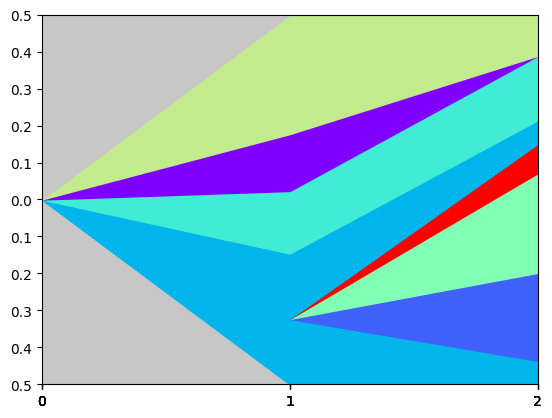

In [3]:
data = pyf.process_data(pop, phylo)
pyf.fish_plot(*data)

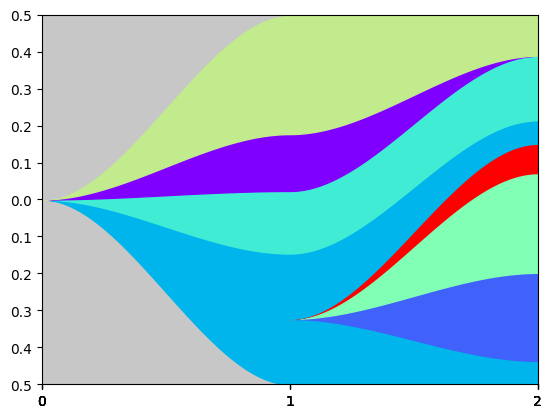

In [4]:
data = pyf.process_data(pop, phylo)
pyf.fish_plot(*data, curved=True)

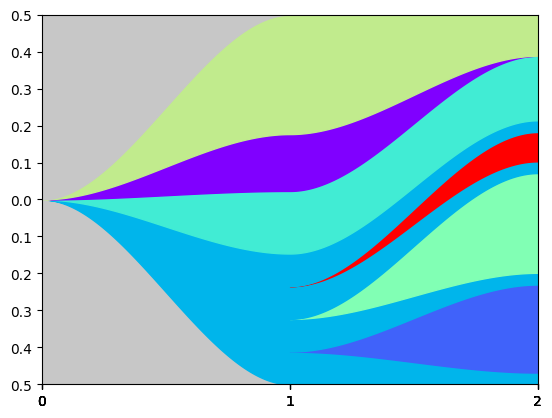

In [9]:
data = pyf.process_data(pop, phylo, separate=True)
pyf.fish_plot(*data, curved=True)

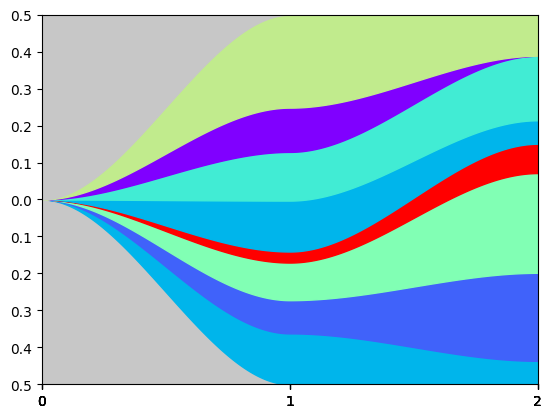

In [10]:
data = pyf.process_data(pop, phylo, interpolate=0)
pyf.fish_plot(*data, curved=True)

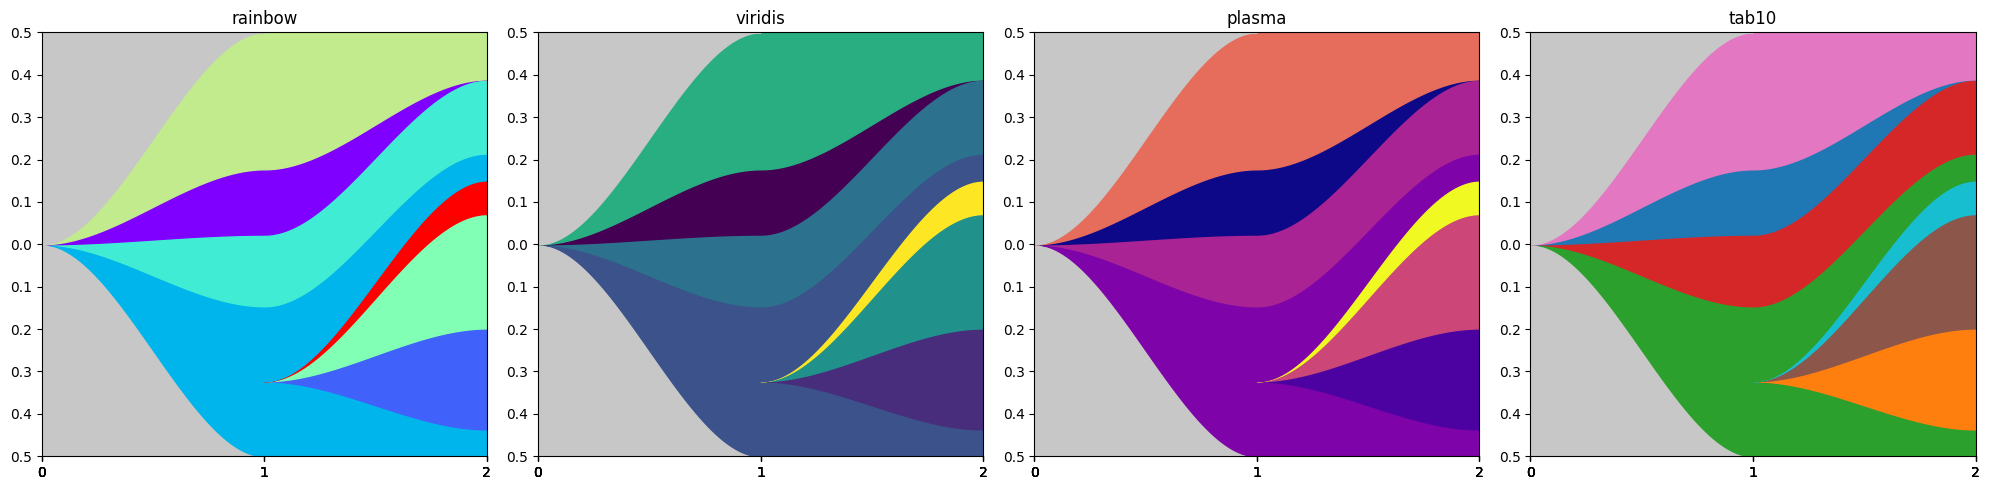

In [12]:
import matplotlib.pyplot as plt

cmaps = ["rainbow", "viridis", "plasma", "tab10"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, cmap in zip(axes, cmaps):
    d = pyf.process_data(pop, phylo, cmap_name=cmap)
    pyf.fish_plot(*d, curved=True, ax=ax)
    ax.set_title(cmap)

plt.tight_layout()
plt.show()


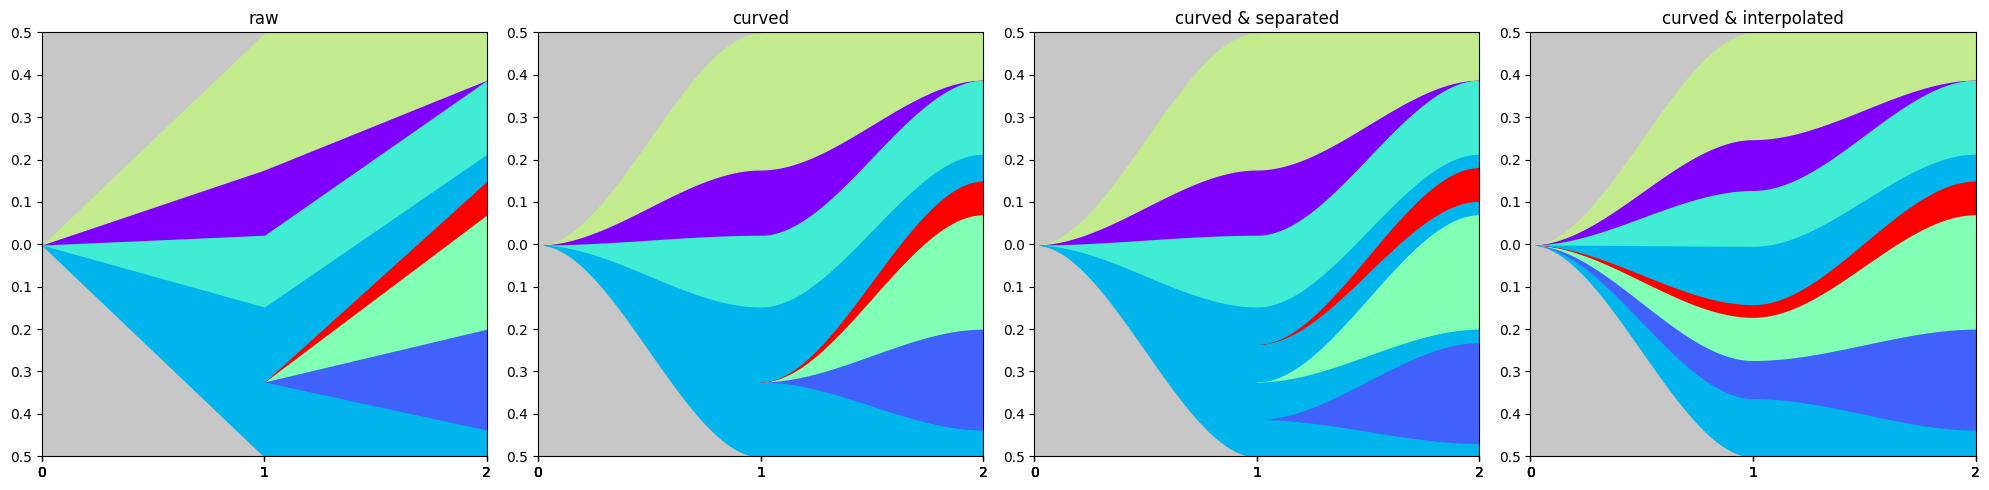

In [11]:
import matplotlib.pyplot as plt

configs = [
    ("raw",                  dict(),                          dict()),
    ("curved",               dict(),                          dict(curved=True)),
    ("curved & separated",   dict(separate=True),             dict(curved=True)),
    ("curved & interpolated",dict(interpolate=0),             dict(curved=True)),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (title, data_kwargs, plot_kwargs) in zip(axes, configs):
    d = pyf.process_data(pop, phylo, **data_kwargs)
    pyf.fish_plot(*d, ax=ax, **plot_kwargs)
    ax.set_title(title)

plt.tight_layout()
plt.show()
